In [1]:
import sys
import os
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from tqdm import tqdm
from PIL import Image
import urllib.request
import io

# Path to the local DINOv3 repository
REPO_DIR = "/Users/loganchoi/Desktop/dinov3/dinov3"
sys.path.append(REPO_DIR)

# Configure device (MPS for Mac GPU, CUDA for Nvidia, CPU otherwise)
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print(f"Using device: {device}")

Using device: mps


In [2]:
# Load the DINOv3 backbone model
print("Loading DINOv3 ViT-S/16...")
model = torch.hub.load(
    REPO_DIR, 
    'dinov3_vits16', 
    source='local', 
    weights='https://huggingface.co/jaychempan/dinov3/resolve/main/dinov3_vits16_pretrain_lvd1689m-08c60483.pth'
)
model = model.to(device)
model.eval()
print("Backbone loaded successfully!")

# Define ImageNet preprocessing transform (resizes images to 224x224)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

Loading DINOv3 ViT-S/16...
Backbone loaded successfully!


In [3]:
print("Downloading/Loading CIFAR-10 dataset...")
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

classes = train_dataset.classes
print("Dataset classes:", classes)


Downloading/Loading CIFAR-10 dataset...
Dataset classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [4]:
# Subset 1000 train images and 200 test images to make it fast
np.random.seed(42)
train_indices = np.random.choice(len(train_dataset), 1000, replace=False)
test_indices = np.random.choice(len(test_dataset), 200, replace=False)

train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)

train_loader = DataLoader(train_subset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=False)

# Extract embeddings for the training set
print("Extracting DINOv3 embeddings for training set (1000 images)...")
X_train, y_train = [], []
with torch.no_grad():
    for images, labels in tqdm(train_loader):
        images = images.to(device)
        features = model.forward_features(images)
        embeddings = features["x_norm_clstoken"].cpu().numpy()
        X_train.append(embeddings)
        y_train.append(labels.numpy())
        
X_train = np.concatenate(X_train, axis=0)
y_train = np.concatenate(y_train, axis=0)

# Extract embeddings for the test set
print("\nExtracting DINOv3 embeddings for test set (200 images)...")
X_test, y_test = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.to(device)
        features = model.forward_features(images)
        embeddings = features["x_norm_clstoken"].cpu().numpy()
        X_test.append(embeddings)
        y_test.append(labels.numpy())

X_test = np.concatenate(X_test, axis=0)
y_test = np.concatenate(y_test, axis=0)


Extracting DINOv3 embeddings for training set (1000 images)...


100%|██████████| 16/16 [00:03<00:00,  4.13it/s]



Extracting DINOv3 embeddings for test set (200 images)...


100%|██████████| 4/4 [00:00<00:00,  5.16it/s]


In [5]:
print("Training Logistic Regression classifier on top of the frozen embeddings...")
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# Evaluate predictions
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\n" + "="*60)
print(f"CLASSIFIER PERFORMANCE (DINOv3 ViT-S/16 + Logistic Regression)")
print(f"Overall Test Accuracy: {accuracy:.2%}")
print("="*60)
print(classification_report(y_test, y_pred, target_names=classes))
print("="*60)

Training Logistic Regression classifier on top of the frozen embeddings...

CLASSIFIER PERFORMANCE (DINOv3 ViT-S/16 + Logistic Regression)
Overall Test Accuracy: 95.00%
              precision    recall  f1-score   support

    airplane       1.00      0.95      0.97        19
  automobile       1.00      1.00      1.00        20
        bird       1.00      0.86      0.93        22
         cat       0.94      0.81      0.87        21
        deer       0.77      0.91      0.83        11
         dog       0.87      1.00      0.93        20
        frog       0.96      0.96      0.96        26
       horse       0.94      1.00      0.97        16
        ship       0.95      1.00      0.97        19
       truck       1.00      1.00      1.00        26

    accuracy                           0.95       200
   macro avg       0.94      0.95      0.94       200
weighted avg       0.95      0.95      0.95       200



Loading image from URL: https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQJHx2iBQYrVsluxUQXztAG2-MblOjPNIQhtpV2pl4c5g&s


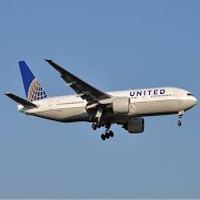


PREDICTED CLASS: AIRPLANE
Confidence Scores:
 - airplane    : 69.9%
 - automobile  : 8.7%
 - bird        : 2.4%
 - cat         : 13.5%
 - deer        : 2.4%
 - dog         : 0.1%
 - frog        : 0.8%
 - horse       : 0.6%
 - ship        : 0.0%
 - truck       : 1.5%


In [7]:
def classify_custom_image(image_path_or_url):
    # Load image from file or URL
    if image_path_or_url.startswith("http://") or image_path_or_url.startswith("https://"):
        print(f"Loading image from URL: {image_path_or_url}")
        with urllib.request.urlopen(image_path_or_url) as url_conn:
            img_data = url_conn.read()
        img = Image.open(io.BytesIO(img_data)).convert("RGB")
    else:
        print(f"Loading local image: {image_path_or_url}")
        img = Image.open(image_path_or_url).convert("RGB")
        
    # Display the image (scaled for reference)
    display(img.resize((200, 200)))
    
    # Preprocess and send to GPU/MPS
    input_tensor = transform(img).unsqueeze(0).to(device)
    
    # Get DINOv3 features
    with torch.no_grad():
        features = model.forward_features(input_tensor)
        embedding = features["x_norm_clstoken"].cpu().numpy()
        
    # Run prediction through the Logistic Regression model
    pred_class_idx = clf.predict(embedding)[0]
    pred_probs = clf.predict_proba(embedding)[0]
    
    print(f"\nPREDICTED CLASS: {classes[pred_class_idx].upper()}")
    print("="*30)
    print("Confidence Scores:")
    for idx, class_name in enumerate(classes):
        print(f" - {class_name:<12}: {pred_probs[idx]:.1%}")

# --- TRY AN IMAGE ---
# Feel free to change this URL to any other image of an airplane, car, cat, dog, bird, horse, deer, frog, ship, or truck!
example_url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQJHx2iBQYrVsluxUQXztAG2-MblOjPNIQhtpV2pl4c5g&s"
classify_custom_image(example_url)

Loading image from URL: https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRGcXUlF6yuihpatydMo7C8r0Q6W2iQbi7Jw4FkBCTnWQ&s=10


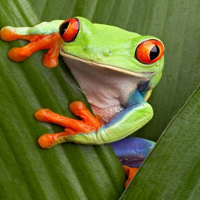


PREDICTED CLASS: FROG
Confidence Scores:
 - airplane    : 0.4%
 - automobile  : 0.1%
 - bird        : 0.1%
 - cat         : 0.0%
 - deer        : 0.0%
 - dog         : 0.2%
 - frog        : 98.8%
 - horse       : 0.1%
 - ship        : 0.1%
 - truck       : 0.2%


In [8]:
example_url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRGcXUlF6yuihpatydMo7C8r0Q6W2iQbi7Jw4FkBCTnWQ&s=10"
classify_custom_image(example_url)